Cognitive Modeling in User Prefernce for MAB selection


Many algorithms today use MAB sampling to determine user prefence, i.e, the winning slot. It would be of beneift for the MAB to learn user prefernce based on the current state, irrespective of previous selections.





In [ ]:
!pip install sympy

ERROR: Could not find a version that satisfies the requirement Ipython.display (from versions: none)
ERROR: No matching distribution found for Ipython.display


In [ ]:
# We define the memoryless property via the following equation
from sympy import symbols, Function, Eq, latex
from IPython.display import display, Math

X, s, t = symbols("X s t", positive=True)

P = Function("P")

memoryless = Eq(
    P(X > s + t, X > s),
    P(X > t)
)

display(Math(latex(memoryless)))

<IPython.core.display.Math object>

In [ ]:
# We further define a small scale multi arm bandit that randomly rewards users for their guesses
import numpy as np

def run_bandit(num_states=5, num_rounds=10):
    true_prefs = np.random.uniform(0, 1, size=num_states)

    history = []

    for r in range(1, num_rounds + 1):
        choice = int(input(f"Round {r}, choose 1-{num_states}: "))

        arm = choice - 1

        # returned preference score between 0 and 1
        reward = np.clip(
            np.random.normal(loc=true_prefs[arm], scale=0.1),
            0,
            1
        )

        history.append((choice, reward))

        print(f"Reward: {reward:.3f}")

    return {
        "history": history,
        "true_prefs": true_prefs
    }

result = run_bandit()

Round 1, choose 1-5: 2
Reward: 0.508
Round 2, choose 1-5: 4
Reward: 0.948
Round 3, choose 1-5: 5
Reward: 0.676
Round 4, choose 1-5: 5
Reward: 0.858
Round 5, choose 1-5: 3
Reward: 0.527
Round 6, choose 1-5: 2
Reward: 0.616
Round 7, choose 1-5: 4
Reward: 0.795
Round 8, choose 1-5: 5
Reward: 0.562
Round 9, choose 1-5: 3
Reward: 0.560
Round 10, choose 1-5: 2
Reward: 0.373


We introduce a 'Memoryless' bandit that treats user prefernce with no known history

In [ ]:
import numpy as np


class UserPreferenceModel:
    def __init__(self, num_arms=5, noise=0.1):
        self.num_arms = num_arms
        self.noise = noise
        self.true_prefs = np.random.uniform(0, 1, size=num_arms)

    def pull(self, arm):
        raise NotImplementedError

    def _noisy_reward(self, mean):
        return np.clip(
            np.random.normal(mean, self.noise),
            0,
            1
        )

    def get_true_prefs(self):
        return self.true_prefs


class MemorylessUser(UserPreferenceModel):
    def pull(self, arm):
        return self._noisy_reward(self.true_prefs[arm])


class DriftingUser(UserPreferenceModel):
    def __init__(self, num_arms=5, noise=0.1, drift=0.03):
        super().__init__(num_arms, noise)
        self.drift = drift

    def pull(self, arm):
        reward = self._noisy_reward(self.true_prefs[arm])

        self.true_prefs += np.random.normal(0, self.drift, size=self.num_arms)
        self.true_prefs = np.clip(self.true_prefs, 0, 1)

        return reward


class MarkovUser(UserPreferenceModel):
    def __init__(self, num_arms=5, noise=0.1):
        super().__init__(num_arms, noise)

        self.transition_matrix = np.random.dirichlet(
            np.ones(num_arms),
            size=num_arms
        )

        self.current_state = np.random.randint(num_arms)

    def pull(self, arm):
        state_bonus = 0.2 if arm == self.current_state else 0.0
        mean = np.clip(self.true_prefs[arm] + state_bonus, 0, 1)

        reward = self._noisy_reward(mean)

        self.current_state = np.random.choice(
            self.num_arms,
            p=self.transition_matrix[self.current_state]
        )

        return reward


class FatigueUser(UserPreferenceModel):
    def __init__(self, num_arms=5, noise=0.1, fatigue_rate=0.05):
        super().__init__(num_arms, noise)
        self.fatigue_rate = fatigue_rate
        self.counts = np.zeros(num_arms)

    def pull(self, arm):
        fatigue_penalty = self.fatigue_rate * self.counts[arm]
        mean = np.clip(self.true_prefs[arm] - fatigue_penalty, 0, 1)

        reward = self._noisy_reward(mean)

        self.counts[arm] += 1

        return reward


class NoveltySeekingUser(UserPreferenceModel):
    def __init__(self, num_arms=5, noise=0.1, novelty_strength=0.2):
        super().__init__(num_arms, noise)
        self.novelty_strength = novelty_strength
        self.counts = np.zeros(num_arms)

    def pull(self, arm):
        novelty_bonus = self.novelty_strength / (1 + self.counts[arm])
        mean = np.clip(self.true_prefs[arm] + novelty_bonus, 0, 1)

        reward = self._noisy_reward(mean)

        self.counts[arm] += 1

        return reward

Summary statistics:


,Model,MSE,RMSE,MAE,Max Abs Error,Error Variance,Correlation
0,Memoryless,0.001052,0.032436,0.029206,0.048626,0.000904,0.993278
3,Fatigue,0.004535,0.067340,0.058426,0.110684,0.004071,0.982950
1,Drifting,0.005531,0.074372,0.061200,0.126576,0.005527,0.893856
2,Markov,0.008603,0.092753,0.088018,0.143056,0.008179,0.934963
4,Novelty,0.013740,0.117219,0.096579,0.193731,0.006814,0.966383


Closest model to true preferences: Memoryless


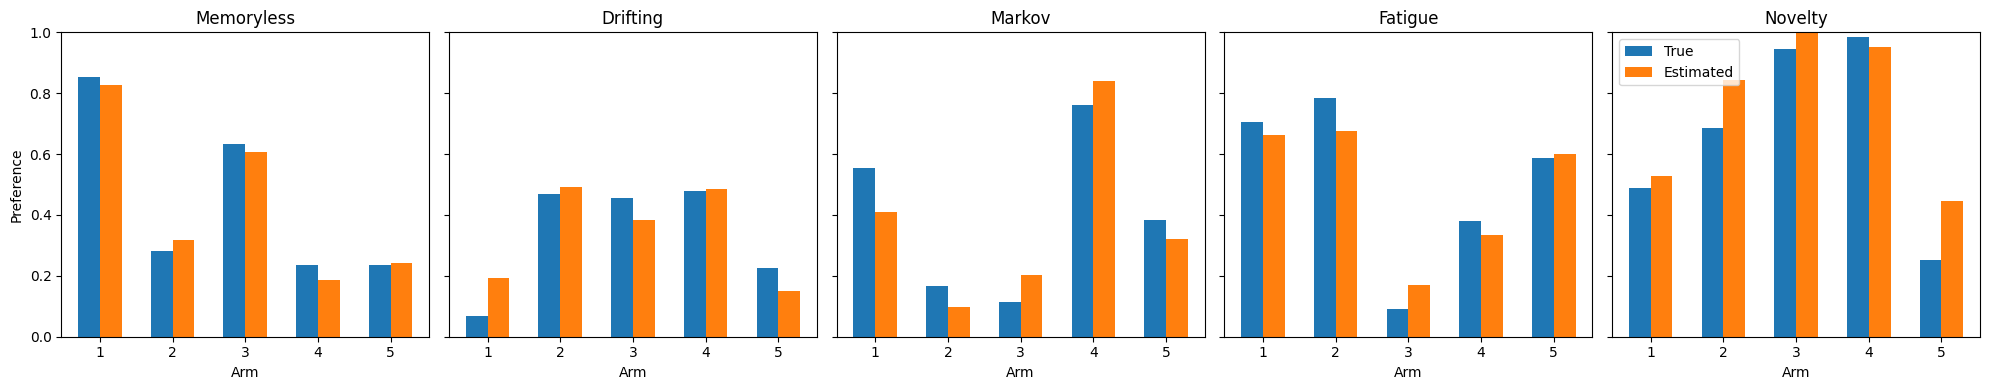

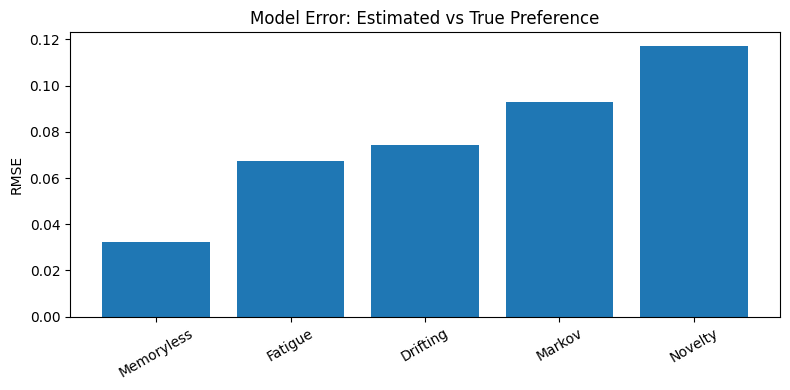

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# assumes these classes already exist:
# MemorylessUser, DriftingUser, MarkovUser, FatigueUser, NoveltySeekingUser

def test_user_model(UserClass, num_arms=5, num_rounds=10, noise=0.1, **kwargs):
    user = UserClass(num_arms=num_arms, noise=noise, **kwargs)

    counts = np.zeros(num_arms)
    estimates = np.zeros(num_arms)

    choices = []
    rewards = []

    # simple exploration: cycle through arms evenly
    for t in range(num_rounds):
        arm = t % num_arms
        reward = user.pull(arm)

        counts[arm] += 1
        estimates[arm] += (reward - estimates[arm]) / counts[arm]

        choices.append(arm)
        rewards.append(reward)

    true_prefs = user.get_true_prefs().copy()
    errors = estimates - true_prefs

    return {
        "true_prefs": true_prefs,
        "estimates": estimates,
        "errors": errors,
        "choices": choices,
        "rewards": rewards,
        "mse": np.mean(errors ** 2),
        "rmse": np.sqrt(np.mean(errors ** 2)),
        "mae": np.mean(np.abs(errors)),
        "max_abs_error": np.max(np.abs(errors)),
        "error_variance": np.var(errors),
        "correlation": np.corrcoef(true_prefs, estimates)[0, 1]
    }


models = {
    "Memoryless": MemorylessUser,
    "Drifting": DriftingUser,
    "Markov": MarkovUser,
    "Fatigue": FatigueUser,
    "Novelty": NoveltySeekingUser
}

results = {}

for name, ModelClass in models.items():
    results[name] = test_user_model(
        ModelClass,
        num_arms=5,
        num_rounds=10,
        noise=0.1
    )


summary = pd.DataFrame([
    {
        "Model": name,
        "MSE": result["mse"],
        "RMSE": result["rmse"],
        "MAE": result["mae"],
        "Max Abs Error": result["max_abs_error"],
        "Error Variance": result["error_variance"],
        "Correlation": result["correlation"]
    }
    for name, result in results.items()
]).sort_values("RMSE")

print("Summary statistics:")
display(summary)

best_model = summary.iloc[0]["Model"]
print(f"Closest model to true preferences: {best_model}")


fig, axes = plt.subplots(1, len(results), figsize=(20, 4), sharey=True)

arms = np.arange(1, 6)

for ax, (name, result) in zip(axes, results.items()):
    ax.bar(arms - 0.15, result["true_prefs"], width=0.3, label="True")
    ax.bar(arms + 0.15, result["estimates"], width=0.3, label="Estimated")

    ax.set_title(name)
    ax.set_xlabel("Arm")
    ax.set_xticks(arms)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Preference")
axes[-1].legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
plt.bar(summary["Model"], summary["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Error: Estimated vs True Preference")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()